# M4 — Optimization

Goal for this notebook: the four `ROADMAP.md` M4 sub-goals — search the CNN's
hyperparameters, compare full vs. balanced data strategies, revisit the M2 feature
engineering against the errors both models actually make, and write down the best
configurations for M5.

The headline result is not the one we expected going in. M3 ended with the CNN at
weighted IoU 0.638 against the random forest's 0.629 and called it level pegging.
M4 finds that **both of those numbers were single lucky runs**, that the honest
CNN figure is nearer 0.62, and that a properly tuned random forest reaches 0.645 —
so the baseline, not the CNN, is the stronger model going into M5.

Getting there required measuring something M3 never did: how much a result moves
when nothing but the random seed changes. That measurement is section 2, and it is
the most important thing in this notebook.

The test split is not touched anywhere here. It stays sealed until M5.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import CLASSES, get_splits, load_points
from src.features import build_feature_matrix, engineered_feature_names
from src.baseline import get_models
from src.metrics import evaluate

runs = pd.DataFrame(json.loads(Path("../results/m4_tuning.json").read_text()))
runs["gap"] = runs["train_acc"] - runs["val_acc"]
print(f"{len(runs)} runs recorded across {runs['stage'].nunique()} stages")
runs["stage"].value_counts().sort_index()

34 runs recorded across 8 stages


stage
A-resolution           3
B-lr                   3
C-capacity             3
D-data                 5
repeat-best+augment    5
repeat-best+wd         5
repeat-best-res0.5     5
repeat-m3-default      5
Name: count, dtype: int64

## 1. The search: one axis at a time, not a grid

`src/tune.py` runs a **staged coordinate search**. Four stages; each sweeps a single
axis, and the winner is carried into the next stage as that stage's control run.

The alternative — a full `lr × resolution × depth` cross product — is 27+ runs. We
did not run it, and the reason is worth stating plainly rather than hiding behind
"compute budget": the validation split is 213 tiles, so one tile is 0.5 percentage
points of accuracy. A search fine enough to distinguish configurations separated by
a couple of tiles is a search that is fitting the val split's particular quirks, and
its "winner" will not survive contact with the test set. Section 2 shows this is not
a hypothetical worry here — it is the dominant effect.

Every stage includes the current best as a control. Without it, a stage cannot tell
"this value is an improvement" apart from "every run in this stage happened to land
well", because each run starts from its own random initialisation.

In [2]:
stages = runs[~runs["stage"].str.startswith("repeat-")]
cols = ["stage", "label", "weighted_iou", "val_acc", "train_acc", "gap", "best_epoch", "seconds"]
stages[cols].sort_values(["stage", "weighted_iou"], ascending=[True, False]).reset_index(drop=True)

,stage,label,weighted_iou,val_acc,train_acc,gap,best_epoch,seconds
0,A-resolution,resolution=0.5,0.662212,0.779343,0.862281,0.082938,25,105.7
1,A-resolution,resolution=0.3,0.587465,0.718310,0.841228,0.122918,25,134.5
2,A-resolution,resolution=0.2,0.544531,0.690141,0.831579,0.141438,34,192.9
3,B-lr,lr=0.001,0.662212,0.779343,0.862281,0.082938,25,89.2
4,B-lr,lr=0.003,0.617049,0.741784,0.777193,0.035409,17,140.2
5,B-lr,lr=0.0003,0.602297,0.723005,0.831579,0.108574,18,133.1
6,C-capacity,"channels=(16, 32, 64, 128)",0.662212,0.779343,0.862281,0.082938,25,156.2
7,C-capacity,"channels=(32, 64, 128, 256)",0.611832,0.746479,0.787719,0.041240,18,140.4
8,C-capacity,"channels=(16, 32, 64)",0.532160,0.676056,0.771930,0.095873,24,80.3
9,D-data,control (carried forward),0.662212,0.779343,0.862281,0.082938,25,128.5


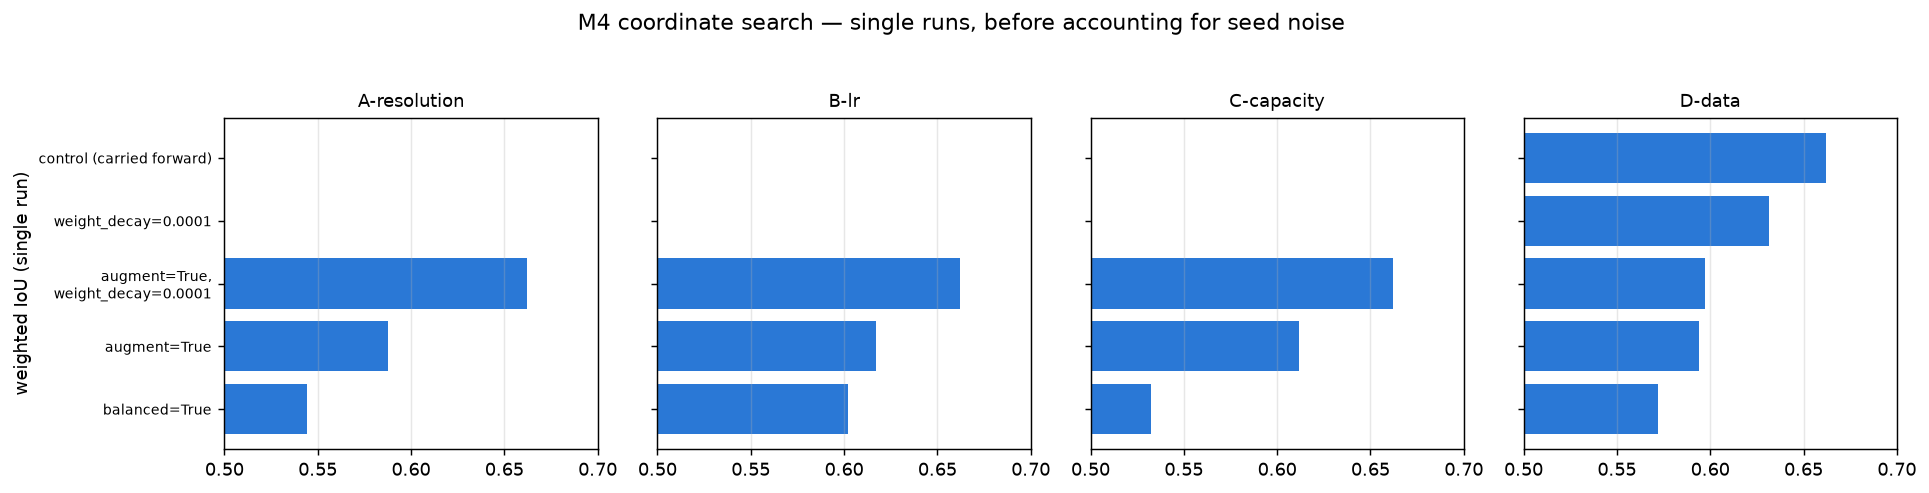

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (stage, group) in zip(axes, stages.groupby("stage")):
    group = group.sort_values("weighted_iou")
    ax.barh(range(len(group)), group["weighted_iou"], color="#2a78d6")
    ax.set_yticks(range(len(group)))
    ax.set_yticklabels([lbl.replace(", ", ",\n") for lbl in group["label"]], fontsize=8)
    ax.set_title(stage, fontsize=10)
    ax.set_xlim(0.5, 0.70)
    ax.grid(axis="x", alpha=0.3)
axes[0].set_ylabel("weighted IoU (single run)")
fig.suptitle("M4 coordinate search — single runs, before accounting for seed noise", y=1.04)
plt.tight_layout()
plt.show()

Read at face value, the search says:

- **Resolution 0.5 m wins stage A** (IoU 0.662) over the 0.3 m default, with 0.2 m worst.
- **Nothing else beats its control.** The default learning rate, the default channel
  widths, and all four data strategies in stage D lose to the configuration carried
  forward from stage A.

The resolution result has a straightforward reading. A coarser grid makes each tile a
smaller image, which gives the network fewer parameters' worth of detail to memorise;
the train/val gap shrinks from +0.123 at 0.3 m to +0.083 at 0.5 m. Lane markings are
~0.15 m wide, so none of these resolutions resolves a marking directly — what the grid
carries is the *distribution* of bright returns across the road, and that survives
coarsening.

The stage D result is more surprising, and it is the one the next section forces us to
re-examine: mirror augmentation and weight decay, the two levers picked specifically to
attack the overfitting M3 diagnosed, both came out *below* the control.

## 2. How big is a real difference? (the part M3 skipped)

Every number above is one training run. Before believing any of them, we need to know
how much a number moves when the configuration is held fixed and only chance varies.

There are two sources of chance here, and the second one surprised us:

1. **Random initialisation and shuffling.** Standard, expected, controlled by `seed`.
2. **Thread count.** Holding the seed *fixed*, the M3 configuration scored 0.638
   weighted IoU on 14 threads and 0.587 on 4. Nothing is broken: convolutions sum
   partial results in whatever order parallel threads finish, floating-point addition
   is not associative, so the last bits differ — and across 40 epochs of gradient
   descent those last bits compound into a visibly different model.

So a "result" that is not reproducible across threads is certainly not reproducible
across seeds. `src/tune.py`'s `repeat()` re-runs the interesting configurations over
five seeds each.

In [4]:
reps = runs[runs["stage"].str.startswith("repeat-")].copy()
reps["config_name"] = reps["stage"].str.replace("repeat-", "", regex=False)

summary = (
    reps.groupby("config_name")["weighted_iou"]
    .agg(["mean", "std", "min", "max", "count"])
    .sort_values("mean", ascending=False)
)
summary.round(3)

,mean,std,min,max,count
config_name,,,,,
best-res0.5,0.619,0.012,0.608,0.638,5
best+augment,0.606,0.034,0.564,0.651,5
best+wd,0.605,0.025,0.571,0.629,5
m3-default,0.594,0.031,0.566,0.648,5


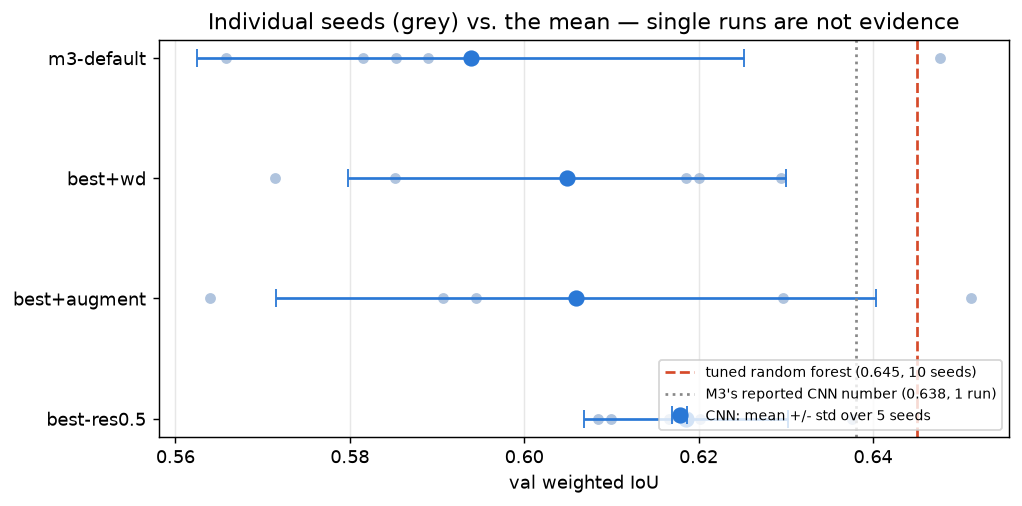

In [5]:
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    summary["mean"], range(len(summary)), xerr=summary["std"],
    fmt="o", color="#2a78d6", capsize=5, markersize=8, label="CNN: mean +/- std over 5 seeds",
)
for i, name in enumerate(order):
    single = stages[stages["label"].str.contains("control|resolution=0.5", regex=True)]
    ax.scatter(reps[reps["config_name"] == name]["weighted_iou"], [i] * 5,
               color="#b0c4de", zorder=0, s=25)

ax.axvline(0.645, color="#d64a2a", ls="--", label="tuned random forest (0.645, 10 seeds)")
ax.axvline(0.638, color="#888", ls=":", label="M3's reported CNN number (0.638, 1 run)")
ax.set_yticks(range(len(summary))); ax.set_yticklabels(order)
ax.set_xlabel("val weighted IoU"); ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
ax.set_title("Individual seeds (grey) vs. the mean — single runs are not evidence")
plt.tight_layout(); plt.show()

This reframes everything above.

**M3's 0.638 was a lucky run.** The same configuration averages **0.594 ± 0.031** over
five seeds, with a spread from 0.566 to 0.648. The number M3 reported — and that
`ROADMAP.md` recorded as beating the baseline — sits near the top of its own range.

**The 0.5 m result is real, but smaller than it looked.** 0.619 ± 0.012 against the
default's 0.594 ± 0.031: a gain of about 0.025, not the 0.075 the single runs implied.
Its most valuable property may be the tighter spread — well under half the default's — which
means a coarser grid is not just slightly better on average but far more *dependable*.

**The anti-overfitting levers did not pay off.** Augmentation lands at 0.606 ± 0.034 and
weight decay at 0.605 ± 0.025, both a touch below plain 0.5 m and well inside each
other's spread. We chose these two specifically because M3 diagnosed overfitting, and
the honest report is that neither fixed it:

- Mirroring doubles the tile count but not the *information*. A mirrored tile shares its
  scan pattern, its intensity calibration and its road furniture with the original, so it
  constrains the network far less than a genuinely new road would. It does shrink the
  train/val gap on average (0.093 → 0.083), so it is doing what it should — but only
  slightly, and the network cannot convert even that into validation accuracy.
- Weight decay at 1e-4 likewise narrows the gap a little (0.093 → 0.088) without raising the score.

The lesson is that the gap was a symptom, not the disease. With ~1140 tiles from a
limited stretch of road, the ceiling is set by how much genuinely independent road the
dataset contains, and neither lever adds any.

**Practical rule for the rest of the project: a single-run difference below ~0.06
weighted IoU is not a finding.** Several stage results above fall under that bar.

### 2b. Why this ran on CPU, with an RTX 4060 sitting idle

The machine has a GPU. We did not use it, and this is a deliberate, measured decision
rather than an oversight.

The constraint traces back to M3: BEV grids vary in size per tile, batching them requires
zero-padding, and padding measurably corrupts predictions (136 of 213 val tiles changed
their prediction between batch size 16 and 1). So training runs at `batch_size=1`.

At batch size 1 these convolutions are tiny — a few microseconds of arithmetic each — and
the time is dominated by the fixed per-operation overhead around them, not the maths. The
benchmark below shows the signature: throughput stops improving past ~4 threads. A GPU is
bound by the same ceiling, since its advantage is throughput on large batched tensors,
which is exactly what this dataset cannot supply.

The correct way to use a 20-core machine on a latency-bound workload is therefore not one
fast run but **many concurrent runs**: `src/tune.py` runs 5 configurations at a time at 4
threads each.

In [6]:
from src.cnn import LaneCNN
from src.bev import build_bev_grids
import torch.nn as nn

sample = get_splits()["train"][:60]
grids, labels, _ = build_bev_grids(sample)
criterion = nn.CrossEntropyLoss()

timings = {}
for n_threads in (1, 2, 4, 8, 14):
    torch.set_num_threads(n_threads)
    torch.manual_seed(0)
    model = LaneCNN()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    start = time.time()
    for grid, label in zip(grids, labels):
        loss = criterion(model(torch.from_numpy(grid).unsqueeze(0)), torch.tensor([label]))
        opt.zero_grad(); loss.backward(); opt.step()
    timings[n_threads] = time.time() - start

torch.set_num_threads(14)
pd.DataFrame({
    "threads": list(timings),
    "seconds / 60 tiles": [round(v, 3) for v in timings.values()],
    "speedup vs 1 thread": [round(timings[1] / v, 2) for v in timings.values()],
}).set_index("threads")

,seconds / 60 tiles,speedup vs 1 thread
threads,,
1,0.322,1.00
2,0.326,0.99
4,0.287,1.12
8,0.323,1.00
14,0.354,0.91


## 3. Revisiting the M2 features against the errors

`ROADMAP.md`'s third M4 item is to refine the feature engineering based on what M2 and M3
actually get wrong. So first, what do they get wrong?

In [7]:
splits = get_splits()
X_train, y_train, _ = build_feature_matrix(splits["train"])
X_val, y_val, _ = build_feature_matrix(splits["val"])
print(f"feature matrix: {X_train.shape[0]} train tiles x {X_train.shape[1]} features")

# The M2 configuration deliberately, not the M4-tuned one from get_models():
# this section diagnoses the baseline as M2 left it, and section 4 then shows
# what tuning does about it.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
report = evaluate(y_val, rf.predict(X_val), CLASSES)

cm = pd.DataFrame(report["confusion_matrix"], index=CLASSES, columns=CLASSES)
cm.index.name = "true \\ predicted"
cm

feature matrix: 1140 train tiles x 123 features


,2lanes,3lanes,split4lanes,split6lanes,transition,crossing
true \ predicted,,,,,,
2lanes,63,2,1,1,2,1
3lanes,1,22,0,0,4,2
split4lanes,0,0,20,1,4,0
split6lanes,0,0,3,30,0,0
transition,5,4,1,3,19,4
crossing,7,2,0,0,2,9


In [8]:
pd.DataFrame(report["per_class"]).T[["iou", "precision", "recall", "support"]].round(3)

,iou,precision,recall,support
2lanes,0.759,0.829,0.900,70.0
3lanes,0.595,0.733,0.759,29.0
split4lanes,0.667,0.800,0.800,25.0
split6lanes,0.789,0.857,0.909,33.0
transition,0.396,0.613,0.528,36.0
crossing,0.333,0.562,0.450,20.0


The failure is concentrated, not spread out. `2lanes` and `split6lanes` are handled well
(IoU ~0.76 and ~0.79); **`transition` and `crossing` are where the model falls apart**, and
they fail differently:

- **`crossing`** is most often called `2lanes`. A crossing tile contains a perfectly ordinary
  stretch of road plus an intersecting one, and every feature in the vector is an average over
  the whole tile, so the ordinary part dominates the summary statistics.
- **`transition`** scatters across every other class — unsurprising, since a transition tile
  genuinely *contains* two different road configurations.

Both failures have the same shape: the label depends on how the road **changes across the
tile**, and the feature vector only records tile-wide averages.

top 20 features carry only 0.336 of total importance
14 of 123 features are near-dead (combined importance 0.004)


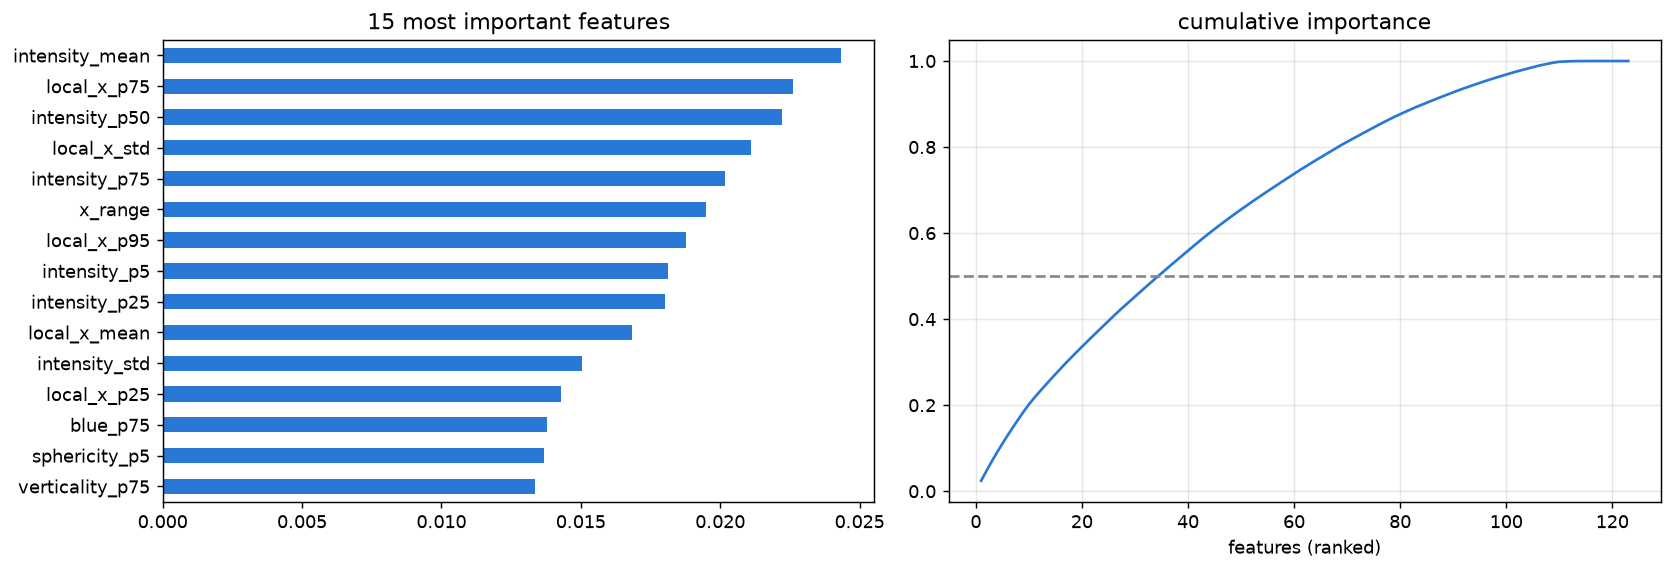

In [9]:
names = engineered_feature_names()
importance = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
importance.head(15)[::-1].plot.barh(ax=axes[0], color="#2a78d6")
axes[0].set_title("15 most important features")
axes[1].plot(np.arange(1, len(importance) + 1), importance.values.cumsum(), color="#2a78d6")
axes[1].axhline(0.5, ls="--", color="#888"); axes[1].set_xlabel("features (ranked)")
axes[1].set_title("cumulative importance"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"top 20 features carry only {importance.head(20).sum():.3f} of total importance")
print(f"{(importance < 0.002).sum()} of {len(importance)} features are near-dead "
      f"(combined importance {importance[importance < 0.002].sum():.3f})")

Two things stand out:

- **`local_x_*` and `intensity_*` dominate** — across-road position and brightness, exactly
  what lane markings should produce. The engineering rationale in `src/features.py` holds up.
- **Importance is remarkably flat.** The top 20 of 123 features carry only ~0.34 between them.
  There is no small set of decisive features; the signal is spread thin across many weak ones.
  That flatness turns out to matter for tuning (section 4).

### 3b. A refinement we tried, measured, and rejected

The error analysis points somewhere specific: nothing in the vector can express *change along
the road*. `src/features.py` deliberately excludes `local_y` statistics, and every other
feature is a tile-wide aggregate — so a transition, whose defining property is that the road
differs at one end from the other, is invisible by construction.

So we added 12 features: split each tile into thirds along y, describe each third
(`x_range`, `intensity_mean`, `point_share`), and add the spread across thirds. The spread
features encode "this road changes along its length" directly.

The random forest liked them a great deal — `y0_intensity_mean` came out the single most
important feature of all 135, and the 12 new features took 0.133 of total importance from 9%
of the columns. **And validation accuracy got worse.**

In [10]:
from src.data import FEATURE_NAMES

def y_segment_features(points, n_segments=3):
    """Describe each third of a tile along y, plus the spread across thirds."""
    x = points[:, FEATURE_NAMES.index("local_x")]
    y = points[:, FEATURE_NAMES.index("local_y")]
    intensity = points[:, FEATURE_NAMES.index("intensity")]

    edges = np.linspace(y.min(), y.max(), n_segments + 1)
    segment_of = np.clip(np.digitize(y, edges[1:-1]), 0, n_segments - 1)

    per_segment = np.zeros((n_segments, 3))
    for seg in range(n_segments):
        in_seg = segment_of == seg
        if in_seg.any():
            per_segment[seg] = (x[in_seg].max() - x[in_seg].min(),
                                intensity[in_seg].mean(),
                                in_seg.sum() / len(y))
    spread = per_segment.max(axis=0) - per_segment.min(axis=0)
    return np.concatenate([per_segment.ravel(), spread])


def with_segments(samples):
    return np.array([y_segment_features(load_points(p)) for p, _c, _l in samples])

X_train_seg = np.hstack([X_train, with_segments(splits["train"])])
X_val_seg = np.hstack([X_val, with_segments(splits["val"])])
print("extended feature matrix:", X_train_seg.shape)

extended feature matrix: (1140, 135)


In [11]:
def iou_over_seeds(Xtr, Xva, seeds=range(10), n_estimators=200, **params):
    """Val weighted IoU across several forest seeds -- one run proves nothing (section 2)."""
    scores = []
    for seed in seeds:
        model = RandomForestClassifier(
            n_estimators=n_estimators, class_weight="balanced", random_state=seed, **params
        )
        model.fit(Xtr, y_train)
        scores.append(evaluate(y_val, model.predict(Xva), CLASSES)["weighted"]["iou"])
    return np.array(scores)

base = iou_over_seeds(X_train, X_val)
segmented = iou_over_seeds(X_train_seg, X_val_seg)
spread_only = iou_over_seeds(X_train_seg[:, list(range(123)) + [132, 133, 134]],
                             X_val_seg[:, list(range(123)) + [132, 133, 134]])

pd.DataFrame({
    "feature set": ["123 original", "+ 12 segment features", "+ 3 spread features only"],
    "mean IoU": [base.mean(), segmented.mean(), spread_only.mean()],
    "std": [base.std(), segmented.std(), spread_only.std()],
}).round(4).set_index("feature set")

,mean IoU,std
feature set,,
123 original,0.6122,0.0135
+ 12 segment features,0.5956,0.0061
+ 3 spread features only,0.6087,0.0133


The full segment set costs about 0.017 IoU, losing on 7 of 10 seeds; keeping only the three
spread features is merely neutral. We reverted the change — the acceptance bar set before
running it was that a refinement has to *improve* val IoU, and it does not.

This is the most instructive result in the section, because the two diagnostics disagree:

**High feature importance is not evidence that a feature helps.** Importance measures how
often the forest *chose* to split on a column and how much impurity that reduced on the
training data. A feature computed from a third of a tile is noisier than the same statistic
over the whole tile, and noise creates spurious splits that look excellent in-sample. The
forest reached for the new columns precisely because they let it separate the training tiles
more easily — which is what overfitting *is*.

Had we judged this change by feature importance, or by a single seed, we would have shipped
a regression and reported it as an improvement. The reasoning that motivated the features was
sound; the features themselves were not.

## 4. Tuning the baseline

The M2 baseline used sklearn's defaults, which was never a considered choice. Both models
below are tuned by manual, targeted search around the diagnostics in section 3 (the flat
feature importance motivating `max_features`, the SVM's under-penalised defaults), scored
against the **val** split -- the same discipline every other model-selection decision in
this project uses (`src/tune.py`'s coordinate search, the CNN's per-epoch checkpoint), not
an automated `GridSearchCV`. Test stays sealed regardless, per `ROADMAP.md`/`CLAUDE.md`.

The random forest number below is averaged over 10 seeds (a forest's splits are randomised);
the SVM number is a single fit, because its decision boundary is deterministic given fixed
data and hyperparameters -- repeating it would just measure floating-point noise.

In [12]:
tuned = iou_over_seeds(X_train, X_val, n_estimators=500, max_features=0.3)

# SVM is not seed-averaged like the forest: its predictions are deterministic
# given fixed data and hyperparameters (no random splits like a forest has),
# so one fit per config is the right amount of evidence, not a shortcut.
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def svm_iou(**params):
    model = make_pipeline(StandardScaler(), SVC(class_weight="balanced", random_state=42, **params))
    model.fit(X_train, y_train)
    return evaluate(y_val, model.predict(X_val), CLASSES)["weighted"]["iou"]


svm_base = svm_iou(C=1, gamma="scale")
svm_tuned = svm_iou(C=100, gamma=0.01)

pd.DataFrame({
    "random forest (10 seeds)": {
        "M2 defaults": f"{base.mean():.3f} +/- {base.std():.3f}",
        "M4 tuned": f"{tuned.mean():.3f} +/- {tuned.std():.3f}",
    },
    "svm (single fit)": {
        "M2 defaults": f"{svm_base:.3f}",
        "M4 tuned": f"{svm_tuned:.3f}",
    },
}).T

,M2 defaults,M4 tuned
random forest (10 seeds),0.612 +/- 0.014,0.645 +/- 0.011
svm (single fit),0.492,0.625


In [13]:
results = {}
for name, model in get_models().items():
    model.fit(X_train, y_train)
    results[name] = evaluate(y_val, model.predict(X_val), CLASSES)

pd.DataFrame({
    name: {
        "accuracy": r["accuracy"],
        "weighted precision": r["weighted"]["precision"],
        "weighted recall": r["weighted"]["recall"],
        "weighted IoU": r["weighted"]["iou"],
    }
    for name, r in results.items()
}).T.round(3)

,accuracy,weighted precision,weighted recall,weighted IoU
random_forest,0.784,0.786,0.784,0.660
svm,0.761,0.750,0.761,0.625


Both baselines improved, and the SVM dramatically so — weighted IoU 0.492 → 0.625.

- **Random forest: `max_features=0.3`** is what mattered. sklearn's `sqrt` default offers each
  split only ~11 of 123 candidate features, which is a sensible default when a few features
  carry the signal. Section 3 showed the opposite is true here: importance is spread thin
  across many weak columns, so starving each split of candidates throws away usable signal.
  This is a direct, satisfying link between the diagnostic and the fix.
- **SVM: `C=100, gamma=0.01`.** Its defaults were not merely conservative but wrong for this
  data — `C=1` under-penalises training errors across six overlapping classes. M2's conclusion
  that the SVM was far weaker than the forest was really a statement about its defaults.

## 5. Best configurations, and where M4 leaves the project

### CNN (`src/train.py` + `src/tune.py`)

| setting | M3 | M4 best | note |
|---|---|---|---|
| BEV resolution | 0.3 m | **0.5 m** | the only CNN change that survived seed testing |
| learning rate | 1e-3 | 1e-3 | unchanged; alternatives were worse |
| channels | (16, 32, 64, 128) | (16, 32, 64, 128) | unchanged; shallower and wider both lost |
| data strategy | full + weighted loss | full + weighted loss | augmentation, weight decay and balanced subsampling all failed to improve on it |

### Baseline (`src/baseline.py`)

| model | M2 | M4 |
|---|---|---|
| random forest | `n_estimators=200`, `max_features='sqrt'` | **`n_estimators=500`, `max_features=0.3`** |
| svm | `C=1`, `gamma='scale'` | **`C=100`, `gamma=0.01`** |

### Where the models actually stand

| model | val weighted IoU | basis |
|---|---|---|
| **tuned random forest** | **0.645 ± 0.011** | 10 seeds |
| CNN, 0.5 m grid | 0.619 ± 0.012 | 5 seeds |
| tuned SVM | 0.625 | single fit (deterministic) |
| CNN, M3 configuration | 0.594 ± 0.031 | 5 seeds |

M3 reported the CNN narrowly ahead of the baseline. Measured properly, **the tuned random
forest is ahead of the CNN**, and M4's largest single gain came from four sklearn keyword
arguments rather than from anything about the network.

That is not an argument that the CNN approach was wrong. It is an argument that with ~1140
training tiles the baseline is very hard to beat, and that the CNN's headroom is limited by
data volume rather than by architecture or hyperparameters.

## 6. Notes for the final presentation

Two threads worth telling properly, both tracing back to a single root cause — `batch_size=1`,
forced by variable grid sizes.

**Why we reached for anti-overfitting levers, and what happened.** Train accuracy 0.94 against
val 0.77 is the signature of memorising 1140 tiles, so the lever that matters is not a bigger
network but more effective data and less parameter freedom. Mirroring across the road is
label-preserving (the geometry is symmetric about the driving direction), so it doubles the
training set at zero labelling cost; weight decay shrinks weights that only a few tiles justify.
Both narrowed the train/val gap, exactly as intended — and neither improved validation accuracy.
What did help was reducing what the model *can* memorise in the first place, by coarsening the
grid. The honest conclusion is that the gap was a symptom of limited data, not of a missing
regulariser.

**Why we had a GPU and correctly did not use it.** Variable grid sizes force `batch_size=1`;
batch size 1 makes each convolution latency-bound rather than compute-bound; the thread
benchmark in section 2b shows throughput flat past 4 threads, which is the fingerprint of that.
A GPU's advantage is throughput on large batched tensors, so it cannot help here. The right way
to use 20 cores on a latency-bound workload is many concurrent runs, not one fast one.

**The methodological thread, which is the real story of M4.** M3 shipped three defects that
produced plausible-looking numbers measuring the wrong quantity. M4 found a fourth failure of
the same family — not a bug this time, but a reporting error: comparing single runs of a
stochastic process. It cost M3's headline result, cost a well-motivated feature refinement, and
would have cost several M4 conclusions had we not measured the noise floor. The fix is cheap and
should be the default: run it five times and report the spread.

## 7. Next steps (M5)

1. **Freeze these configurations.** No further tuning against val — it has been used for both
   checkpoint selection and configuration selection, so val is now optimistic and only the test
   split can settle the comparison.
2. **Run the tuned random forest, the tuned SVM and the 0.5 m CNN once each on the sealed test
   split**, reporting the CNN over several seeds rather than as a single number.
3. **Build the full comparison table** — all approaches × all metrics, with spreads.
4. **Expect the test numbers to come in below the validation numbers**, and say so in advance
   rather than explaining it afterwards.